Import library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

Load Dataset

In [ ]:
# Load dataset awal
df_og = pd.read_excel("gabungan-data-cuaca-serang.xlsx")

# Nama kolom dataset awal
col_name = ["TN", "TX", "TAVG", "RH_AVG", "RR", "SS", "FF_X", "DDD_X", "FF_AVG", "DDD_CAR"]

# Cek data awal sebelum data preparation
print("=== Contoh Isi Dataset Original (5 Pertama) ===")
print(df_og.head())
print("=== Contoh Isi Dataset Original (5 Terakhir) ===")
print(df_og.tail())

print("=== Tipe Data Original ===")
print(df_og.dtypes)
print("\n === Nilai Statistik Data Original ===")
print(df_og.describe())
print("\n === Jumlah Nilai dalam Data Original ===")
for i in range(len(col_name)):
    print("\n",col_name[i],":")
    print(df_og[col_name[i]].value_counts())
print("\n === Nilai Data Original ===")
for i in range(len(col_name)):
    print("\n",col_name[i],":")
    print(df_og[col_name[i]].unique())


=== Contoh Isi Dataset Original (5 Pertama) ===
      TANGGAL    TN    TX  TAVG  RH_AVG      RR   SS  FF_X  DDD_X  FF_AVG  \
0  01-04-2024  26.0  33.8  28.1    84.0    18.0  2.1     3    230       1   
1  02-04-2024  25.2  33.2  28.9    86.0  8888.0  4.7     3    360       1   
2  03-04-2024  26.6  33.8  27.5    90.0  8888.0  1.8     4     30       1   
3  04-04-2024  25.4  34.8  29.3    82.0    11.3  2.6     5    320       1   
4  05-04-2024  25.6  34.2  30.2    79.0     0.0  7.8     4    340       1   

  DDD_CAR  
0      C   
1      C   
2      C   
3      C   
4      C   
=== Contoh Isi Dataset Original (5 Terakhir) ===
        TANGGAL    TN    TX  TAVG  RH_AVG      RR   SS  FF_X  DDD_X  FF_AVG  \
725  27-03-2026  24.9  32.0  27.5    83.0    10.0  8.0     3     97       1   
726  28-03-2026  25.1  32.1  27.8    79.0     0.6  8.0     2    221       1   
727  29-03-2026  24.2  33.8  28.4    79.0  8888.0  7.8     4    158       1   
728  30-03-2026  25.0  34.1  28.3    78.0     0.2  8

Data Preparation

In [3]:
# Drop duplikat dan buat dataframe untuk data preparation
df_edit = df_og.drop_duplicates(ignore_index=True)

# Format ulang
df_edit["TANGGAL"] = pd.to_datetime(df_edit["TANGGAL"], format="%d-%m-%Y")
df_edit["DDD_CAR"] = df_edit["DDD_CAR"].astype("string")
df_edit["DDD_CAR"] = df_edit["DDD_CAR"].str.strip()

print(df_edit["DDD_CAR"].value_counts())

# Menangani NAN
invalid_vals = [8888, 9999]
variables = ["TN", "TX", "TAVG", "RH_AVG", "RR", "SS"]

for col in variables:
    df_edit.loc[df_edit[col].isin(invalid_vals), col] = np.nan
    df_edit[col] = df_edit[col].fillna(df_edit[col].median())

# Konversi: DDD_CAR menjadi one hot encoding
df_edit["DDD_CAR"] = df_edit["DDD_CAR"].astype("category")
df_edit = pd.get_dummies(df_edit, columns=["DDD_CAR"], drop_first=False)

# Konversi: DDD_X menjadi nilai sinus dan cosinus
df_edit["SIN_DDD_X"] = np.sin(np.deg2rad(df_edit["DDD_X"]))
df_edit["COS_DDD_X"] = np.cos(np.deg2rad(df_edit["DDD_X"]))

# Tambah kolom kelas curah hujan dan tukar nilai curah hujan (mm) ke tidak hujan/hujan
df_edit["C_RR"] = df_edit["RR"].apply(lambda x: False if x < 0.5 else True)

DDD_CAR
C     356
SW    155
S      81
W      68
N      29
NW     21
NE      7
E       7
SE      6
Name: count, dtype: Int64


Cek ulang data setelah data preparation

In [4]:
# Nama Kolom setelah data preparation
col_name = ["TN", "TX", "TAVG", "RH_AVG", "RR", "SS", "FF_X", "DDD_X", "FF_AVG", "DDD_CAR_C", "DDD_CAR_E", "DDD_CAR_N", "DDD_CAR_NE",
       "DDD_CAR_NW", "DDD_CAR_S", "DDD_CAR_SE", "DDD_CAR_SW", "DDD_CAR_W", "SIN_DDD_X", "COS_DDD_X", "C_RR"]

# Cek data setelah data preparation
print("Column name: ", df_edit.columns)
print("Column Shape:", df_edit.shape)
print("\nCovariance:\n", df_edit.cov())
print("\nCorrelation:\n", df_edit.corr())

print("=== Contoh Isi Dataset Preprocessed (5 Pertama) ===")
print(df_edit.head())
print("=== Contoh Isi Dataset Preprocessed (5 Terakhir) ===")
print(df_edit.tail())

print("=== Tipe Data Original ===")
print(df_edit.dtypes)
print("\n === Nilai Statistik Data Preprocessed ===")
print(df_edit.describe())
print("\n === Jumlah Nilai dalam Data Preprocessed ===")
for i in range(len(col_name)):
    print("\n",col_name[i],":")
    print(df_edit[col_name[i]].value_counts())
print("\n === Nilai Data Preprocessed ===")
for i in range(len(col_name)):
    print("\n",col_name[i],":")
    print(df_edit[col_name[i]].unique())

Column name:  Index(['TANGGAL', 'TN', 'TX', 'TAVG', 'RH_AVG', 'RR', 'SS', 'FF_X', 'DDD_X',
       'FF_AVG', 'DDD_CAR_C', 'DDD_CAR_E', 'DDD_CAR_N', 'DDD_CAR_NE',
       'DDD_CAR_NW', 'DDD_CAR_S', 'DDD_CAR_SE', 'DDD_CAR_SW', 'DDD_CAR_W',
       'SIN_DDD_X', 'COS_DDD_X', 'C_RR'],
      dtype='object')
Column Shape: (730, 22)

Covariance:
                  TANGGAL            TN            TX          TAVG  \
TANGGAL     3.319606e+32 -1.317031e+15 -8.022821e+15 -5.217013e+15   
TN         -1.317031e+15  8.589977e-01  8.591535e-02  3.643126e-01   
TX         -8.022821e+15  8.591535e-02  2.783739e+00  1.311322e+00   
TAVG       -5.217013e+15  3.643126e-01  1.311322e+00  1.040195e+00   
RH_AVG     -1.934821e+16  6.162578e-01 -5.856064e+00 -3.460891e+00   
RR          1.897281e+16 -2.507663e+00 -8.825558e+00 -4.986529e+00   
SS          1.534087e+16 -7.438018e-02  5.976523e-01  1.469600e-01   
FF_X       -4.227970e+15  3.150290e-02  3.279371e-01  2.024663e-01   
DDD_X       6.179647e+17  5.7162

Visualisasi Data

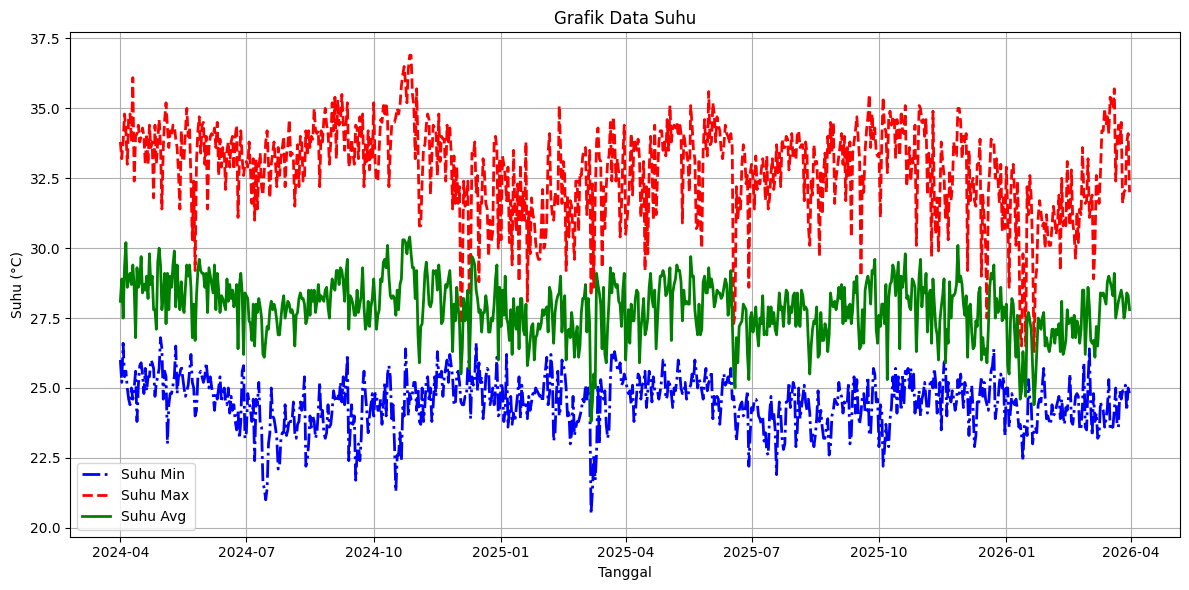

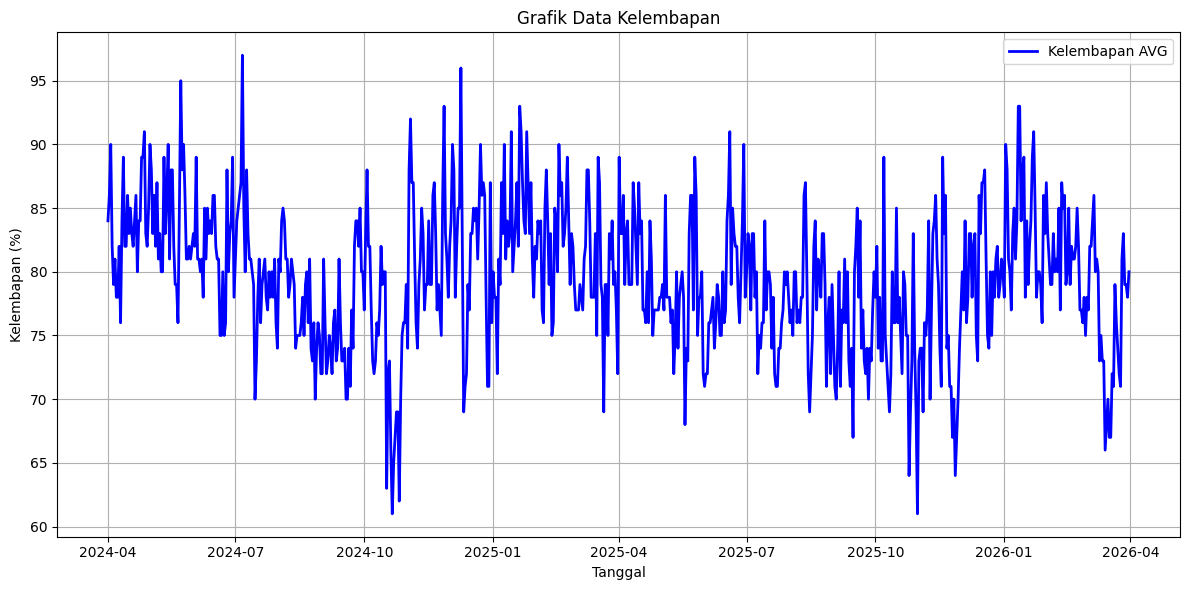

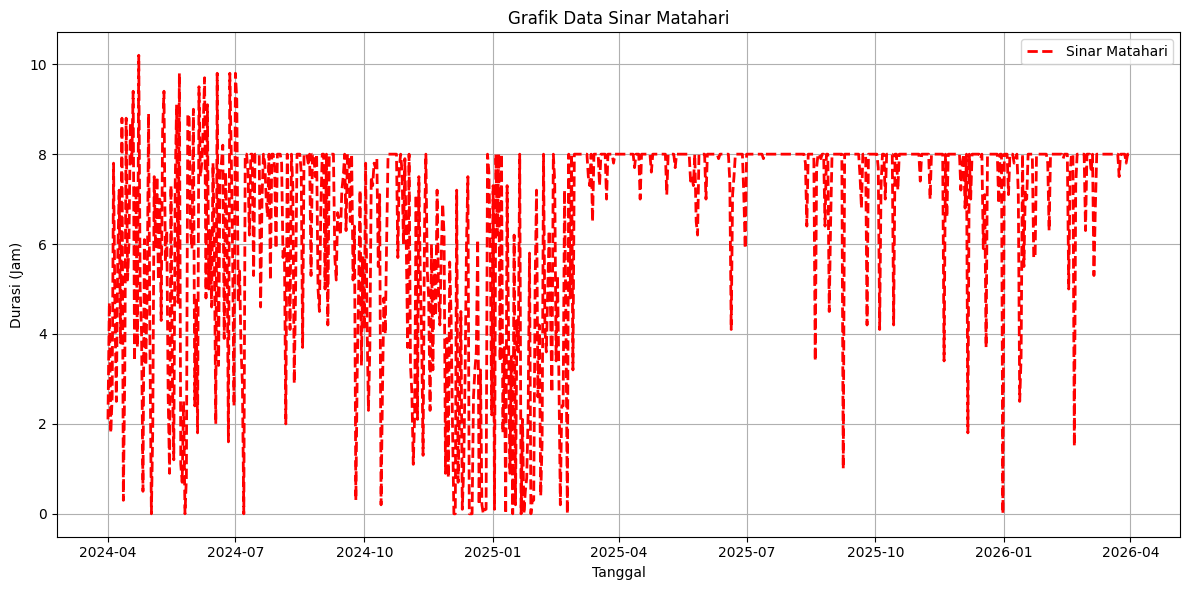

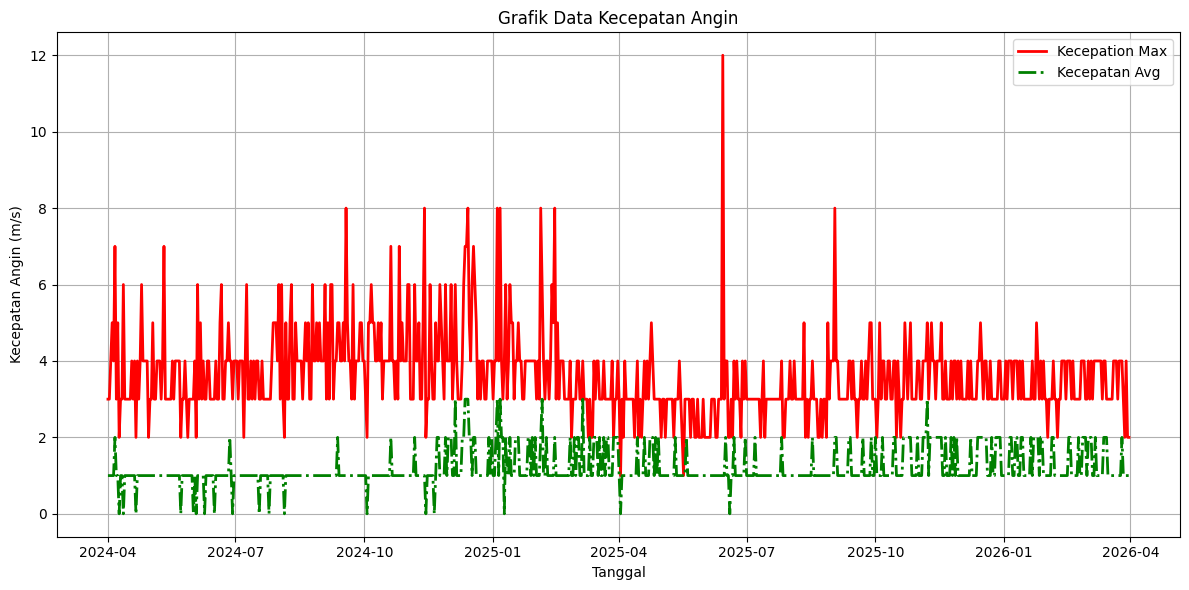

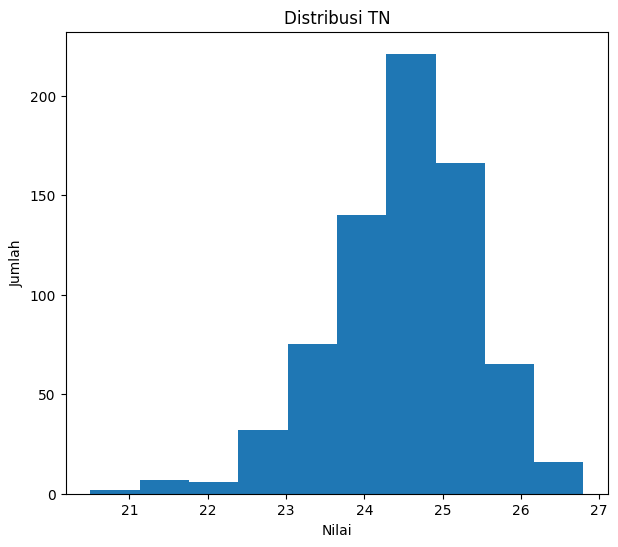

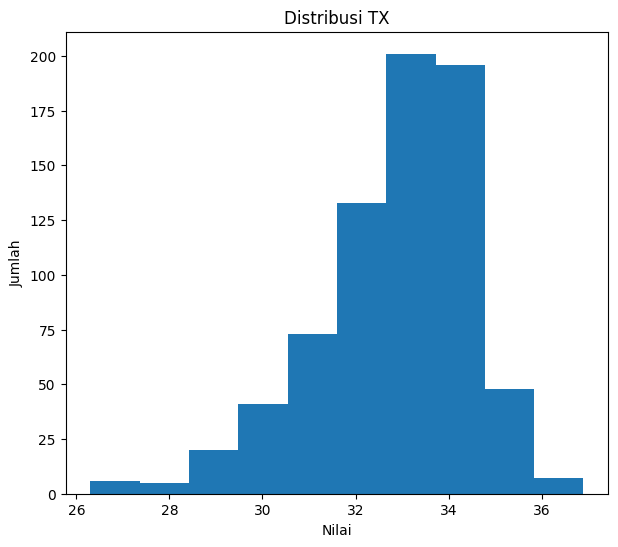

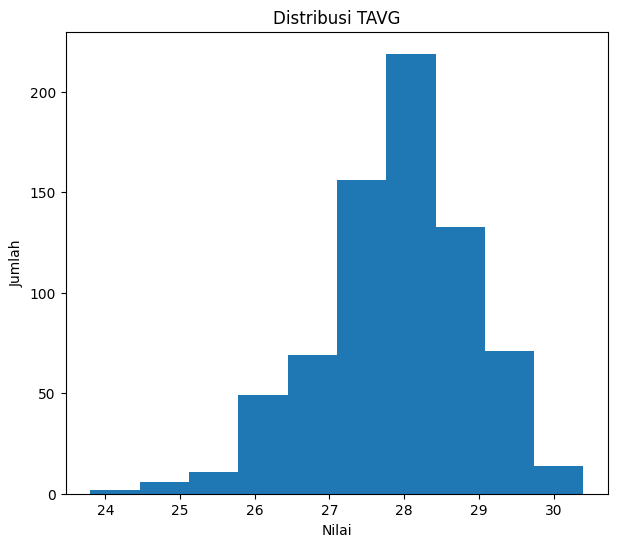

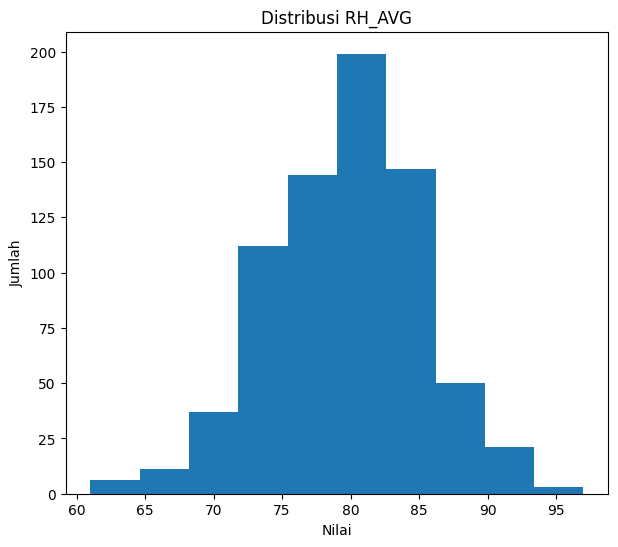

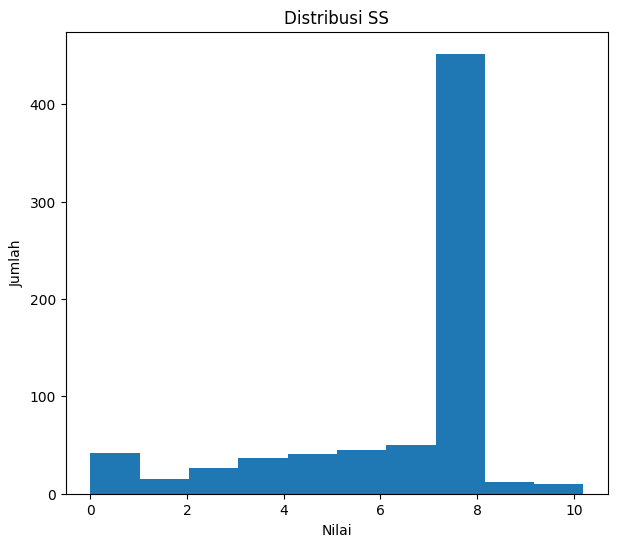

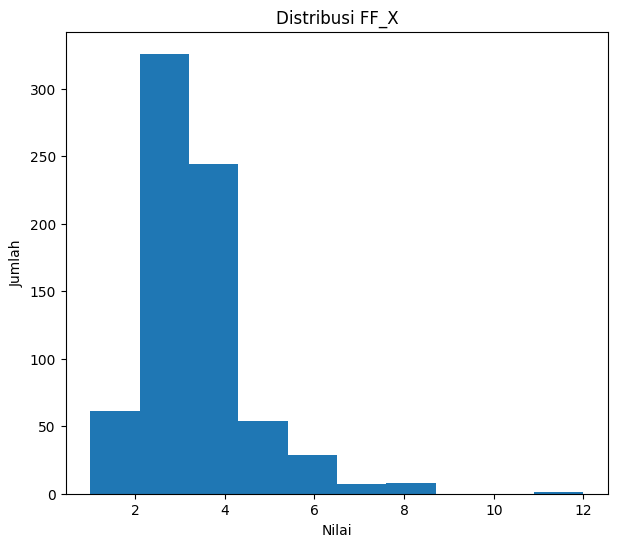

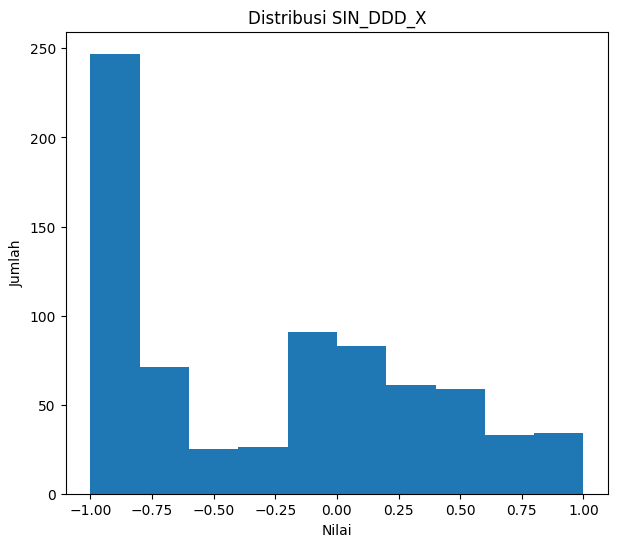

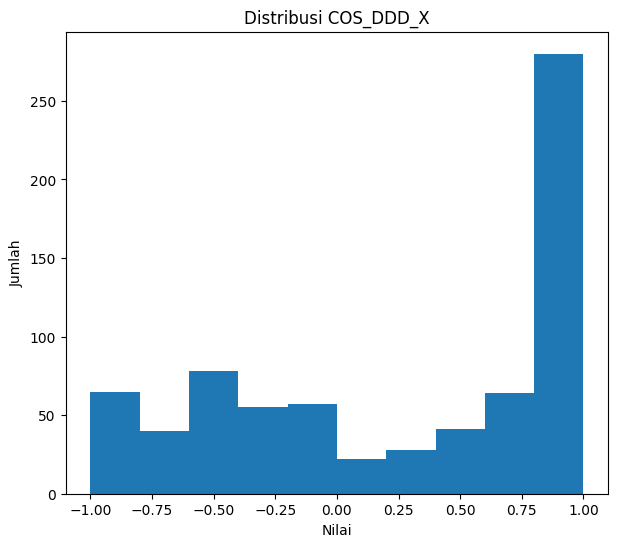

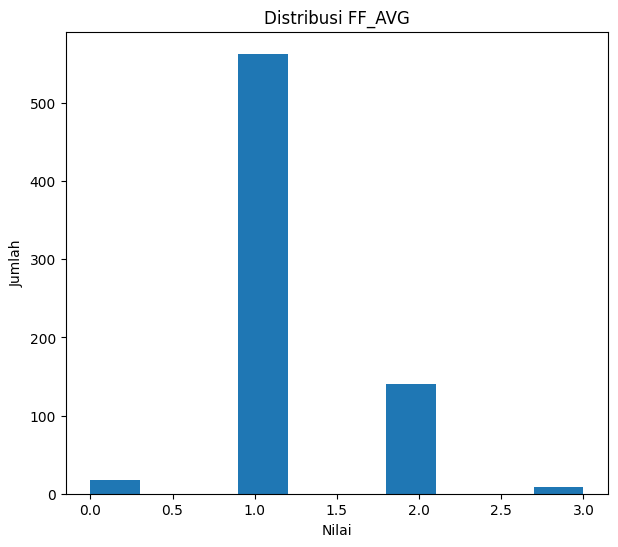

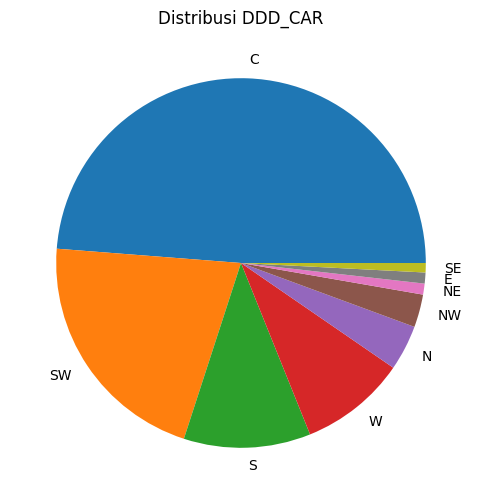

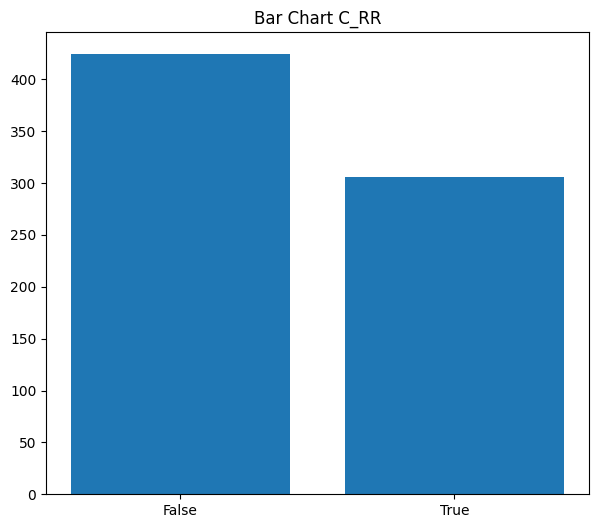

In [5]:
# Membuat folder
if not os.path.exists("figures/Clean Data/"):
  os.makedirs("figures/Clean Data/")


# Membuat Grafik Line Chart Suhu
plt.figure(figsize=(12, 6))
plt.plot(df_edit["TANGGAL"], df_edit["TN"], label="Suhu Min", color="blue", ls = "-.",
         lw = 2)
plt.plot(df_edit["TANGGAL"], df_edit["TX"], label="Suhu Max", color="red", ls = "--",
         lw = 2)
plt.plot(df_edit["TANGGAL"], df_edit["TAVG"], label="Suhu Avg", color="green", ls = "-",
         lw = 2)
plt.xlabel("Tanggal")
plt.ylabel("Suhu (°C)")
plt.title("Grafik Data Suhu")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/Clean Data/GrafikSuhu.png")

# Membuat Grafik Line Chart Kelembapan
plt.figure(figsize=(12, 6))
plt.plot(df_edit["TANGGAL"], df_edit["RH_AVG"], label="Kelembapan AVG", color="blue",
         ls = "-", lw = 2)
plt.xlabel("Tanggal")
plt.ylabel("Kelembapan (%)")
plt.title("Grafik Data Kelembapan")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/Clean Data/GrafikLembap.png")

# Membuat Grafik Line Chart Lama Penerangan Matahari
plt.figure(figsize=(12, 6))
plt.plot(df_edit["TANGGAL"], df_edit["SS"], label="Sinar Matahari", color="red",
         ls = "--", lw = 2)
plt.xlabel("Tanggal")
plt.ylabel("Durasi (Jam)")
plt.title("Grafik Data Sinar Matahari")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/Clean Data/GrafikDurasiJamSinarMatahari.png")

# Membuat Grafik Line Chart Kecepatan Angin
plt.figure(figsize=(12, 6))
plt.plot(df_edit["TANGGAL"], df_edit["FF_X"], label="Kecepation Max", color="red",
         ls = "-", lw = 2)
plt.plot(df_edit["TANGGAL"], df_edit["FF_AVG"], label="Kecepatan Avg", color="green",
         ls = "-.", lw = 2)
plt.xlabel("Tanggal")
plt.ylabel("Kecepatan Angin (m/s)")
plt.title("Grafik Data Kecepatan Angin")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/Clean Data/GrafikKecepatanAngin.png")


# Distribusi Suhu Minimum
plt.figure(figsize=(7, 6))
plt.hist(df_edit["TN"])
plt.title("Distribusi TN")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.savefig("figures/Clean Data/DistTN.png")

# Distribusi Suhu Maksimum
plt.figure(figsize=(7, 6))
plt.hist(df_edit["TX"])
plt.title("Distribusi TX")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.savefig("figures/Clean Data/DistTX.png")

# Distribusi Suhu Rata-Rata
plt.figure(figsize=(7, 6))
plt.hist(df_edit["TAVG"])
plt.title("Distribusi TAVG")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.savefig("figures/Clean Data/DistTAVG.png")

# Distribusi Kelembapan Rata-Rata
plt.figure(figsize=(7, 6))
plt.hist(df_edit["RH_AVG"])
plt.title("Distribusi RH_AVG")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.savefig("figures/Clean Data/DistRHAVG.png")

# Distribusi Lama Penerangan Matahari
plt.figure(figsize=(7, 6))
plt.hist(df_edit["SS"])
plt.title("Distribusi SS")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.savefig("figures/Clean Data/DistSS.png")

# Distribusi Kecepatan Angin Maksimum
plt.figure(figsize=(7, 6))
plt.hist(df_edit["FF_X"])
plt.title("Distribusi FF_X")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.savefig("figures/Clean Data/DistFFX.png")

# Distribusi saat Nilai Sinus Kecepatan Angin Maksimum
plt.figure(figsize=(7, 6))
plt.hist(df_edit["SIN_DDD_X"])
plt.title("Distribusi SIN_DDD_X")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.savefig("figures/Clean Data/DistSINDDDX.png")

# Distribusi saat Nilai Cosinus Kecepatan Angin Maksimum
plt.figure(figsize=(7, 6))
plt.hist(df_edit["COS_DDD_X"])
plt.title("Distribusi COS_DDD_X")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.savefig("figures/Clean Data/DistCOSDDDX.png")

# Distribusi Kecepatan Angin Rata-Rata
plt.figure(figsize=(7, 6))
plt.hist(df_edit["FF_AVG"])
plt.title("Distribusi FF_AVG")
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
plt.savefig("figures/Clean Data/DistFFAVG.png")

# Distribusi Kategori Mata Angin
counts = [356, 155, 81, 68, 29, 21, 7, 7, 6]
labels = ['C', 'SW', 'S', 'W', 'N', 'NW', 'NE', 'E', 'SE']
plt.figure(figsize=(7, 6))
plt.pie(counts, labels=labels)
plt.title("Distribusi DDD_CAR")
plt.savefig("figures/Clean Data/DistDDDCAR.png")

# Distribusi Kelas Hari Hujan
label_rain = ['False', 'True']
count_rain = [424, 306]
plt.figure(figsize=(7, 6))
plt.bar(label_rain, count_rain, label=label_rain)
plt.title("Bar Chart C_RR")
plt.savefig("figures/Clean Data/BarCRR.png")

Simpan data

In [ ]:
df_edit.to_excel('data-cuaca-serang_klasifikasi-biner.xlsx', index=False)